In [1]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset
import optuna
import torch.nn as nn
import sklearn

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Load data
def load_embeddings(file_path):
    print(f"Loading embeddings from {file_path}...")
    df = pd.read_pickle(file_path)
    df["MatchID"] = df["ID"].apply(lambda x: x.split("_")[0])  # Extract MatchID from ID
    print(f"Loaded {len(df)} PeriodIDs.")
    return df

train_file_lstm = "processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels.pkl"
test_file_lstm = "processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl"

train_df_lstm = load_embeddings(train_file_lstm)
test_df_lstm = load_embeddings(test_file_lstm)

Loading embeddings from processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels.pkl...
Loaded 2137 PeriodIDs.
Loading embeddings from processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl...
Loaded 516 PeriodIDs.


In [3]:
class LSTMAttentionModel(nn.Module):
    def __init__(self, input_dim=256, reduced_dim=256, hidden_dim=128, dropout=0.35, num_classes=2):
        super().__init__()
        self.embedding_reduction = nn.Linear(input_dim, reduced_dim)
        self.batch_norm1 = nn.BatchNorm1d(reduced_dim)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(reduced_dim, hidden_dim, num_layers=1, bidirectional=False, batch_first=True)
        self.batch_norm2 = nn.BatchNorm1d(hidden_dim)
        self.residual = nn.Linear(reduced_dim, hidden_dim)  # Residual connection
        self.attention = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        reduced = self.embedding_reduction(x)
        reduced = self.batch_norm1(reduced.permute(0, 2, 1)).permute(0, 2, 1)
        reduced = self.dropout(torch.relu(reduced))

        lstm_out, _ = self.lstm(reduced)
        lstm_out = self.batch_norm2(lstm_out.permute(0, 2, 1)).permute(0, 2, 1)

        # Add residual connection
        combined_out = lstm_out + self.residual(reduced)

        attention_weights = torch.softmax(self.attention(combined_out), dim=1)
        context_vector = torch.sum(attention_weights * combined_out, dim=1)

        return self.fc(context_vector)

In [4]:
# Create game-based data loaders
def create_game_based_data_loaders(df, batch_size, sequence_length, shuffle=True):
    game_loaders = {}
    grouped = df.groupby("MatchID")

    for match_id, group in grouped:
        all_embeddings = np.vstack(group["aggregated_embedding"].values).astype(np.float32)
        all_labels = group["EventType"].values.astype(int)

        sequences, labels = [], []
        for i in range(len(all_embeddings)):
            if i < sequence_length - 1:
                num_pads = sequence_length - 1 - i
                seq_emb = np.vstack((np.zeros((num_pads, all_embeddings.shape[1])), all_embeddings[:i + 1]))
                label = all_labels[i]
            else:
                seq_emb = all_embeddings[i - sequence_length + 1 : i + 1]
                label = all_labels[i]

            sequences.append(seq_emb)
            labels.append(label)

        dataset = TensorDataset(
            torch.tensor(sequences, dtype=torch.float32),
            torch.tensor(labels, dtype=torch.long),
        )
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
        game_loaders[match_id] = loader

    return game_loaders

In [5]:
def evaluate_model(model, loaders, device):
    model.eval()
    all_preds, all_labels = [], []
    confusion_matrix = np.zeros((2, 2), dtype=int)

    with torch.no_grad():
        for _, loader in loaders.items():
            for embeddings, labels in loader:
                embeddings, labels = embeddings.to(device), labels.to(device)
                outputs = model(embeddings)
                _, preds = torch.max(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                confusion_matrix += sklearn.metrics.confusion_matrix(labels.cpu().numpy(), preds.cpu().numpy(), labels=[0, 1])

    accuracy = sklearn.metrics.accuracy_score(all_labels, all_preds)
    return accuracy, confusion_matrix

In [6]:
import torch
from torch import nn
import copy

def train_model(
    model,
    train_df,
    val_df,
    sequence_length,
    batch_size,
    epochs,
    base_lr,
    max_lr,
    device,
    patience=(5, 0.01),
    clip_norm=1.0,
    weight_decay=1e-4
):
    """
    Train the model with or without a validation set.

    Args:
        model (nn.Module): The model to train.
        train_df (pd.DataFrame): Training DataFrame.
        val_df (pd.DataFrame or None): Validation DataFrame. If None, training is without validation.
        sequence_length (int): Length of input sequences.
        batch_size (int): Batch size for training.
        epochs (int): Maximum number of training epochs.
        base_lr (float): Base learning rate for the optimizer.
        max_lr (float): Maximum learning rate for the scheduler.
        device (torch.device): Device to run the training on (CPU or CUDA).
        patience (tuple, optional): (patience_epochs, delta) for early stopping.
                                     Defaults to (5, 0.01).
        clip_norm (float, optional): Maximum norm for gradient clipping. Defaults to 1.0.
        weight_decay (float, optional): L2 regularization weight. Defaults to 1e-4.

    Returns:
        nn.Module: Trained model with the best validation accuracy (if validation is provided).
                   Otherwise, the model trained on the entire training set.
    """
    # Create DataLoaders for training (and validation if provided)
    train_loaders = create_game_based_data_loaders(train_df, batch_size, sequence_length, shuffle=True)
    
    if val_df is not None:
        val_loaders = create_game_based_data_loaders(val_df, batch_size, sequence_length, shuffle=False)
        
        # Initialize optimizer and scheduler
        optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.5,
            patience=3,
            verbose=True
        )
        
        # Loss function
        criterion = nn.CrossEntropyLoss()
        
        # Early Stopping parameters
        patience_epochs, delta = patience
        best_val_acc = 0.0
        best_model_state = None
        early_stop_counter = 0
        
        for epoch in range(epochs):
            model.train()
            total_loss = 0.0
            train_correct = 0
            train_total = 0
            
            # Training loop
            for _, loader in train_loaders.items():
                for embeddings, labels in loader:
                    embeddings = embeddings.to(device)
                    labels = labels.to(device)
                    
                    optimizer.zero_grad()
                    outputs = model(embeddings)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    
                    # Gradient clipping
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
                    
                    optimizer.step()
                    
                    total_loss += loss.item()
                    _, preds = torch.max(outputs, dim=1)
                    train_correct += (preds == labels).sum().item()
                    train_total += labels.size(0)
            
            train_acc = train_correct / train_total
            avg_loss = total_loss / train_total
            
            # Evaluation on validation set
            val_acc, val_confusion = evaluate_model(model, val_loaders, device)
            
            # Scheduler step based on validation accuracy
            scheduler.step(val_acc)
            
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
            print("Confusion Matrix:\n", val_confusion)
            
            # Early Stopping check
            if val_acc > best_val_acc + delta:
                best_val_acc = val_acc
                best_model_state = copy.deepcopy(model.state_dict())
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience_epochs:
                    print("Early stopping triggered.")
                    break
        
        # Load the best model state if validation was used
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
    
    else:
        # Training without validation
        # Initialize optimizer and scheduler
        optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=10,
            gamma=0.1
        )
        
        # Loss function
        criterion = nn.CrossEntropyLoss()
        
        for epoch in range(epochs):
            model.train()
            total_loss = 0.0
            train_correct = 0
            train_total = 0
            
            # Training loop
            for _, loader in train_loaders.items():
                for embeddings, labels in loader:
                    embeddings = embeddings.to(device)
                    labels = labels.to(device)
                    
                    optimizer.zero_grad()
                    outputs = model(embeddings)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    
                    # Gradient clipping
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
                    
                    optimizer.step()
                    
                    total_loss += loss.item()
                    _, preds = torch.max(outputs, dim=1)
                    train_correct += (preds == labels).sum().item()
                    train_total += labels.size(0)
            
            train_acc = train_correct / train_total
            avg_loss = total_loss / train_total
            
            # Scheduler step
            scheduler.step()
            
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}, Train Acc: {train_acc:.4f}")
    
    return model


In [7]:
def fine_tune_model(cv_data, device, n_trials=50):
    """
    Fine-tune hyperparameters using Optuna.

    Args:
        cv_data (list): Cross-validation data (train/validation splits).
        device (torch.device): Device to run the training on.
        n_trials (int): Number of trials for Optuna hyperparameter optimization.

    Returns:
        dict: Best hyperparameters found by Optuna.
    """
    def objective(trial):
        sequence_length = trial.suggest_int("sequence_length", 3, 10)
        reduced_dim = trial.suggest_int("reduced_dim", 128, 512)
        hidden_dim = trial.suggest_int("hidden_dim", 64, 512)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
        max_lr = trial.suggest_float("max_lr", lr * 2, lr * 10, log=True)
        batch_size = trial.suggest_int("batch_size", 16, 128)
        patience = trial.suggest_categorical("patience", [(5, 0.01), (10, 0.05)])
        clip_norm = trial.suggest_float("clip_norm", 0.5, 5.0)

        model = LSTMAttentionModel(
            input_dim=256,
            reduced_dim=reduced_dim,
            hidden_dim=hidden_dim,
            dropout=dropout,
            num_classes=2
        ).to(device)

        val_accuracies = []
        for train_df_cv, val_df_cv in cv_data:
            model_fold = LSTMAttentionModel(
                input_dim=256,
                reduced_dim=reduced_dim,
                hidden_dim=hidden_dim,
                dropout=dropout,
                num_classes=2
            ).to(device)

            trained_model = train_model(
                model=model_fold,
                train_df=train_df_cv,
                val_df=val_df_cv,
                sequence_length=sequence_length,
                batch_size=batch_size,
                epochs=20,
                base_lr=lr,
                max_lr=max_lr,
                device=device,
                patience=patience,
                clip_norm=clip_norm
            )

            val_loaders = create_game_based_data_loaders(val_df_cv, batch_size, sequence_length, shuffle=False)
            val_accuracy, _ = evaluate_model(trained_model, val_loaders, device)
            val_accuracies.append(val_accuracy)

        return np.mean(val_accuracies)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    print(f"Best Hyperparameters: {best_params}")
    return best_params


In [8]:
def create_game_based_sequences_with_ids(df, sequence_length):
    """
    Create sequences and corresponding last IDs from the DataFrame.

    Args:
        df (pd.DataFrame): DataFrame with 'MatchID', 'aggregated_embedding', and 'ID'.
        sequence_length (int): Length of each sequence.

    Returns:
        tuple: (sequences, dummy_labels, ids)
            - sequences: List of numpy arrays representing sequences.
            - dummy_labels: List of dummy labels (e.g., all zeros).
            - ids: List of last IDs in each sequence.
    """
    sequences = []
    dummy_labels = []
    ids = []
    grouped = df.groupby("MatchID")

    for match_id, group in grouped:
        try:
            all_embeddings = np.vstack(group["aggregated_embedding"].values).astype(np.float32)
            all_ids = group["ID"].values
        except ValueError as e:
            print(f"Error processing MatchID '{match_id}': {e}. Skipping this game.")
            continue

        for i in range(len(all_embeddings)):
            if i < sequence_length - 1:
                num_pads = sequence_length - 1 - i
                seq_emb = np.vstack((np.zeros((num_pads, all_embeddings.shape[1])), all_embeddings[:i + 1]))
                last_id = all_ids[i]
            else:
                seq_emb = all_embeddings[i - sequence_length + 1 : i + 1]
                last_id = all_ids[i]
            sequences.append(seq_emb)
            dummy_labels.append(0)  # Dummy label
            ids.append(last_id)

    return sequences, dummy_labels, ids


def predict_for_submission(model, test_df, device, sequence_length, batch_size=32):
    """
    Generate predictions for the test set and prepare the Kaggle submission.

    Args:
        model (nn.Module): Trained LSTMAttentionModel.
        test_df (pd.DataFrame): Test DataFrame containing 'MatchID', 'aggregated_embedding', and 'ID'.
        device (torch.device): Device to run the prediction on (CPU or CUDA).
        sequence_length (int): Length of input sequences.
        batch_size (int, optional): Batch size for DataLoader. Defaults to 32.

    Returns:
        pd.DataFrame: DataFrame containing 'ID' and 'EventType' predictions suitable for Kaggle submission.
    """
    model.eval()  # Set model to evaluation mode
    sequences, _, ids = create_game_based_sequences_with_ids(test_df, sequence_length)
    
    # Create a TensorDataset with dummy labels since they are not used during prediction
    dataset = TensorDataset(
        torch.tensor(sequences, dtype=torch.float32),
        torch.tensor([0]*len(sequences), dtype=torch.long)  # Dummy labels
    )
    
    # Create DataLoader for the test set
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    predictions = []  # List to store predictions
    
    with torch.no_grad():
        for seq_emb, _ in loader:
            seq_emb = seq_emb.to(device)  # Move data to the appropriate device
            outputs = model(seq_emb)      # Forward pass
            _, preds = torch.max(outputs, dim=1)  # Get the predicted class indices
            predictions.extend(preds.cpu().numpy())  # Move predictions to CPU and add to the list
    
    # Create the submission DataFrame
    submission_df = pd.DataFrame({
        'ID': ids,
        'EventType': predictions
    })
    
    return submission_df


In [9]:
best_params = {'sequence_length': 7, 'reduced_dim': 500, 'hidden_dim': 127, 'dropout': 0.4962477396198329, 'lr': 0.0003980527385095304, 'max_lr': 0.0011597380761702056, 'batch_size': 76, 'patience': (5, 0.01), 'clip_norm': 1.899730203295853}

In [10]:
# 7. Train on all data (16 games) with best hyperparameters

# Initialize the final model
final_model_lstm = LSTMAttentionModel(
    input_dim=256,
    reduced_dim=best_params["reduced_dim"],
    hidden_dim=best_params["hidden_dim"],
    dropout=best_params["dropout"],
    num_classes=2
).to(device)


# Train the final model
final_model_lstm = train_model(
    model=final_model_lstm,
    train_df=train_df_lstm,
    val_df=None,
    sequence_length=best_params["sequence_length"],
    batch_size=best_params["batch_size"],
    epochs=30,  # Early stopping manages stopping earlier if needed
    base_lr=best_params["lr"],
    max_lr=best_params["max_lr"],
    device=device
)


C:\Users\sandr\AppData\Local\Temp\ipykernel_3704\2755934727.py:24: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  torch.tensor(sequences, dtype=torch.float32),


Epoch 1/30, Loss: 0.0105, Train Acc: 0.6425
Epoch 2/30, Loss: 0.0093, Train Acc: 0.7122
Epoch 3/30, Loss: 0.0088, Train Acc: 0.7281
Epoch 4/30, Loss: 0.0087, Train Acc: 0.7272
Epoch 5/30, Loss: 0.0082, Train Acc: 0.7529
Epoch 6/30, Loss: 0.0083, Train Acc: 0.7436
Epoch 7/30, Loss: 0.0079, Train Acc: 0.7651
Epoch 8/30, Loss: 0.0078, Train Acc: 0.7674
Epoch 9/30, Loss: 0.0079, Train Acc: 0.7768
Epoch 10/30, Loss: 0.0079, Train Acc: 0.7688
Epoch 11/30, Loss: 0.0074, Train Acc: 0.7885
Epoch 12/30, Loss: 0.0072, Train Acc: 0.7978
Epoch 13/30, Loss: 0.0074, Train Acc: 0.7978
Epoch 14/30, Loss: 0.0071, Train Acc: 0.8049
Epoch 15/30, Loss: 0.0073, Train Acc: 0.8007
Epoch 16/30, Loss: 0.0072, Train Acc: 0.7997
Epoch 17/30, Loss: 0.0070, Train Acc: 0.7997
Epoch 18/30, Loss: 0.0072, Train Acc: 0.8025
Epoch 19/30, Loss: 0.0070, Train Acc: 0.8072
Epoch 20/30, Loss: 0.0071, Train Acc: 0.7997
Epoch 21/30, Loss: 0.0070, Train Acc: 0.8011
Epoch 22/30, Loss: 0.0071, Train Acc: 0.8049
Epoch 23/30, Loss: 

---
---
# Tree Based Method

Training set has 2137 entries.
Loading embeddings from processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels.pkl...
Loaded 2137 PeriodIDs.
(2137, 4)
Number of PCA components to retain 80% variance: 1


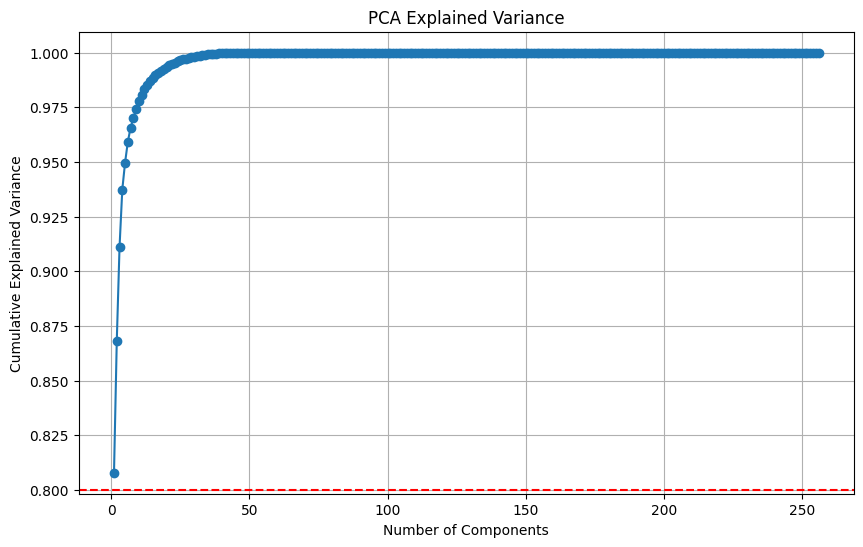

PCA reduced embeddings to 25 dimensions.
(2137, 37)
   EventType  Hashtags Count  Exclamation_Count  TweetLength  \
0        0.0        1.475610           0.170732    55.878049   
1        0.0        1.338028           0.295775    49.563380   
2        0.0        1.578313           0.253012    51.987952   
3        0.0        1.406250           0.322917    46.572917   
4        0.0        0.811189           0.251748    42.790210   

   TweetCount_PerPeriod  Team_Score  Previous1_TweetFreq  Previous2_TweetFreq  \
0                  82.0        40.0                  0.0                  0.0   
1                  71.0        40.0                 82.0                  0.0   
2                  83.0        40.0                 71.0                 82.0   
3                  96.0        40.0                 83.0                 71.0   
4                 143.0        40.0                 96.0                 83.0   

   Previous3_TweetFreq  Previous4_TweetFreq  ...    PCA_16    PCA_17  \
0   

In [11]:
def load_embeddings(file_path):
    print(f"Loading embeddings from {file_path}...")
    df = pd.read_pickle(file_path)
    df["MatchID"] = df["ID"].apply(lambda x: x.split("_")[0])  # Extract MatchID from ID
    print(f"Loaded {len(df)} PeriodIDs.")
    return df

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import optuna
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import mode

train_df_rf = pd.read_csv("features.csv")

all_games = train_df_rf["MatchID"].unique()

np.random.seed(42)


print(f"Training set has {len(train_df_rf)} entries.")

train_file = "processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels.pkl"
embeddings_rf = load_embeddings(train_file)
embeddings_rf["MatchID"] = embeddings_rf["MatchID"].astype(int)

print(embeddings_rf.shape)

# Extract embeddings
train_embeddings_rf = np.vstack(embeddings_rf['aggregated_embedding'].values)  # Shape: (num_train_samples, 256)

# Standardize embeddings
scaler = StandardScaler()
train_embeddings_scaled_rf = scaler.fit_transform(train_embeddings_rf)

# Determine number of components to retain 80% variance
pca_full = PCA().fit(train_embeddings_scaled_rf)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f"Number of PCA components to retain 80% variance: {n_components_80}")

plt.figure(figsize=(10,6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.80, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

# Apply PCA with 25 components or n_components_80, whichever is larger
desired_components = max(25, n_components_80)
pca = PCA(n_components=desired_components, random_state=42)
train_embeddings_pca = pca.fit_transform(train_embeddings_scaled_rf)

print(f"PCA reduced embeddings to {desired_components} dimensions.")

# Create DataFrames for PCA components
train_pca_df_rf = pd.DataFrame(train_embeddings_pca, columns=[f'PCA_{i+1}' for i in range(desired_components)])

# Add the ID column to the PCA DataFrames for merging
train_pca_df_rf['ID'] = embeddings_rf['ID'].values


# Merge the PCA DataFrames with the original DataFrames using the ID column
train_merged_df = pd.merge(train_df_rf, train_pca_df_rf, on='ID')

# Remove the ID column from the merged DataFrames
train_merged_df.drop(columns=['ID'], inplace=True)

# Assuming macro features are all columns except 'MatchID', 'PeriodID'
macro_columns = [col for col in train_merged_df.columns if col not in ['MatchID', 'PeriodID']]

train_features_rf = train_merged_df[macro_columns]

print(train_features_rf.shape)
print(train_features_rf.head())

In [12]:
# Encode target
if 'EventType' not in train_features_rf.columns:
    raise ValueError("EventType not found in the training features.")

y = train_features_rf['EventType'].values
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Drop EventType from training features
train_features_rf = train_features_rf.drop(columns=['EventType'])

print(f"Encoded classes: {le.classes_}")
print(f"Training features shape: {train_features_rf.shape}")

Encoded classes: [0. 1.]
Training features shape: (2137, 36)


In [13]:
y_encoded

array([0, 0, 0, ..., 1, 1, 1], dtype=int64)

In [14]:
train_features_rf

,Hashtags Count,Exclamation_Count,TweetLength,TweetCount_PerPeriod,Team_Score,Previous1_TweetFreq,Previous2_TweetFreq,Previous3_TweetFreq,Previous4_TweetFreq,Previous5_TweetFreq,...,PCA_16,PCA_17,PCA_18,PCA_19,PCA_20,PCA_21,PCA_22,PCA_23,PCA_24,PCA_25
0,1.475610,0.170732,55.878049,82.0,40.0,0.0,0.0,0.0,0.0,0.0,...,-1.025392,-2.018831,-0.454738,0.259431,-0.602401,0.765251,1.857558,2.583195,0.182787,-0.108985
1,1.338028,0.295775,49.563380,71.0,40.0,82.0,0.0,0.0,0.0,0.0,...,-0.869136,-1.106672,0.214099,1.513868,-0.214236,1.244303,0.603390,2.598015,-0.246501,-0.027538
2,1.578313,0.253012,51.987952,83.0,40.0,71.0,82.0,0.0,0.0,0.0,...,0.143242,-0.519176,0.577384,0.478078,-0.024400,1.234804,1.390982,1.696848,0.282669,-0.144241
3,1.406250,0.322917,46.572917,96.0,40.0,83.0,71.0,82.0,0.0,0.0,...,0.358742,-0.945933,0.266748,0.707204,0.747707,0.593417,0.534819,1.212988,-0.441946,-0.108806
4,0.811189,0.251748,42.790210,143.0,40.0,96.0,83.0,71.0,82.0,0.0,...,0.551067,-2.248629,0.422607,0.817172,-1.178647,1.276281,0.678764,4.748997,0.267962,0.362547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2132,2.634698,0.769397,42.695043,928.0,12.0,1043.0,1183.0,735.0,481.0,543.0,...,0.246118,-0.063973,-0.297858,0.634636,0.522579,0.349804,-0.312167,-0.109393,-0.181231,0.022490
2133,2.638298,0.713948,43.645390,846.0,12.0,928.0,1043.0,1183.0,735.0,481.0,...,0.499833,0.486490,0.485280,-0.036136,0.583879,-0.433223,-0.399056,0.029005,-0.269373,0.231596
2134,2.663252,0.604353,45.226633,781.0,12.0,846.0,928.0,1043.0,1183.0,735.0,...,0.798023,0.166604,0.483381,-0.567531,0.595591,-0.620280,-0.309971,0.089543,-0.412528,-0.138535
2135,2.633782,0.602392,45.035874,669.0,12.0,781.0,846.0,928.0,1043.0,1183.0,...,0.590522,0.471565,0.342252,-0.431110,1.072489,-0.580092,-0.328792,0.243027,-0.485672,0.020219


In [15]:
# Use all games for cross-validation
unique_games = np.unique(all_games)
np.random.seed(42)
shuffled_games = np.random.permutation(unique_games)

n_splits = 5
folds = np.array_split(shuffled_games, n_splits)

X = train_features_rf
y = y_encoded
game_ids = train_df_rf['MatchID'].values

fold_indices = []
for fold_games in folds:
    val_mask = np.isin(game_ids, fold_games)
    val_idx = np.where(val_mask)[0]
    train_idx = np.where(~val_mask)[0]
    fold_indices.append((train_idx, val_idx))

print("Created game-based fold indices using all games.")

Created game-based fold indices using all games.


In [16]:
best_params_rf = {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}

accuracies = []
for (train_idx, val_idx) in fold_indices:
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    # Re-initialize the model to ensure no data leakage
    # Since best_models already have chosen parameters, we clone them:
    from sklearn.base import clone
    model = RandomForestClassifier(random_state=42, **best_params_rf)
    model.fit(X_train_fold, y_train_fold)
    preds = model.predict(X_val_fold)
    acc = accuracy_score(y_val_fold, preds)
    accuracies.append(acc)

np.mean(accuracies)

0.7660599601909425

In [17]:
best_final_model_rf = RandomForestClassifier(random_state=42, **best_params_rf)
best_final_model_rf.fit(X, y)

# Load final test set for submission
test_file = "processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl"
final_test_df_rf = pd.read_csv("val_features.csv")  # Macro features without embeddings
final_test_embeddings_rf = load_embeddings(test_file)  # Embeddings for the test set

# Extract and scale embeddings for test set
print("Preparing final test embeddings...")
test_embeddings_rf = np.vstack(final_test_embeddings_rf['aggregated_embedding'].values)
test_embeddings_scaled_rf = scaler.transform(test_embeddings_rf)  # scaler fitted on training embeddings

# Apply PCA
test_embeddings_pca_rf = pca.transform(test_embeddings_scaled_rf)  # pca fitted on training embeddings

print(f"Test embeddings PCA shape: {test_embeddings_pca_rf.shape}")

# Create DataFrame for PCA components in test set
pca_columns = [f'PCA_{i+1}' for i in range(pca.n_components_)]
test_pca_df = pd.DataFrame(test_embeddings_pca_rf, columns=pca_columns)
test_pca_df['ID'] = final_test_embeddings_rf['ID'].values

# Merge PCA embeddings with macro features in final_test_df
final_merged_test_df_rf = pd.merge(final_test_df_rf, test_pca_df, on='ID', how='inner')

# Remove ID and any unnecessary columns (e.g., 'MatchID', 'PeriodID', 'EventType' if present)
columns_to_remove = ['ID', 'MatchID', 'PeriodID', 'EventType']
final_merged_test_df_rf.drop(columns=[c for c in columns_to_remove if c in final_merged_test_df_rf.columns], inplace=True, errors='ignore')

print("Final test features shape:", final_merged_test_df_rf.shape)

# Predict on the final test set
print("Predicting on final test set...")
final_preds = best_final_model_rf.predict(final_merged_test_df_rf)
final_preds_labels = le.inverse_transform(final_preds)

submission = pd.DataFrame({
    "ID": final_test_df_rf["ID"],
    "EventType": final_preds_labels
})
submission.to_csv("Tree_RF_submission_copy.csv", index=False)
print("Final submission 'submission.csv' created successfully.")

Loading embeddings from processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl...
Loaded 516 PeriodIDs.
Preparing final test embeddings...
Test embeddings PCA shape: (516, 25)
Final test features shape: (516, 36)
Predicting on final test set...
Final submission 'submission.csv' created successfully.


---
# Ensemble Method

In [18]:
# import torch.nn.functional as F

# class LSTMAttentionModel(nn.Module):
#     def __init__(self, input_dim=256, reduced_dim=256, hidden_dim=128, dropout=0.35, num_classes=2):
#         super().__init__()
#         self.embedding_reduction = nn.Linear(input_dim, reduced_dim)
#         self.batch_norm1 = nn.BatchNorm1d(reduced_dim)
#         self.dropout = nn.Dropout(dropout)
#         self.lstm = nn.LSTM(reduced_dim, hidden_dim, num_layers=1, bidirectional=False, batch_first=True)
#         self.batch_norm2 = nn.BatchNorm1d(hidden_dim)
#         self.residual = nn.Linear(reduced_dim, hidden_dim)  # Residual connection
#         self.attention = nn.Linear(hidden_dim, 1)
#         self.fc = nn.Linear(hidden_dim, num_classes)

#     def forward(self, x):
#         reduced = self.embedding_reduction(x)
#         reduced = self.batch_norm1(reduced.permute(0, 2, 1)).permute(0, 2, 1)
#         reduced = self.dropout(torch.relu(reduced))

#         lstm_out, _ = self.lstm(reduced)
#         lstm_out = self.batch_norm2(lstm_out.permute(0, 2, 1)).permute(0, 2, 1)

#         # Add residual connection
#         combined_out = lstm_out + self.residual(reduced)

#         attention_weights = torch.softmax(self.attention(combined_out), dim=1)
#         context_vector = torch.sum(attention_weights * combined_out, dim=1)
        
#         output = self.fc(context_vector)
        
#         return F.sigmoid(output) # Apply sigmoid here to get probabilities

In [19]:
best_params = {'sequence_length': 7, 'reduced_dim': 500, 'hidden_dim': 127, 'dropout': 0.4962477396198329, 'lr': 0.0003980527385095304, 'max_lr': 0.0011597380761702056, 'batch_size': 76, 'patience': (5, 0.01), 'clip_norm': 1.899730203295853}

In [20]:
# 7. Train on all data (16 games) with best hyperparameters

# Initialize the final model
final_model = LSTMAttentionModel(
    input_dim=256,
    reduced_dim=best_params["reduced_dim"],
    hidden_dim=best_params["hidden_dim"],
    dropout=best_params["dropout"],
    num_classes=2
).to(device)

all_train_df = load_embeddings(train_file) 

# Train the final model
final_model = train_model(
    model=final_model,
    train_df=all_train_df,
    val_df=None,
    sequence_length=best_params["sequence_length"],
    batch_size=best_params["batch_size"],
    epochs=30,  # Early stopping manages stopping earlier if needed
    base_lr=best_params["lr"],
    max_lr=best_params["max_lr"],
    device=device
)

Loading embeddings from processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels.pkl...
Loaded 2137 PeriodIDs.
Epoch 1/30, Loss: 0.0097, Train Acc: 0.6734
Epoch 2/30, Loss: 0.0088, Train Acc: 0.7305
Epoch 3/30, Loss: 0.0085, Train Acc: 0.7384
Epoch 4/30, Loss: 0.0087, Train Acc: 0.7361
Epoch 5/30, Loss: 0.0083, Train Acc: 0.7529
Epoch 6/30, Loss: 0.0080, Train Acc: 0.7562
Epoch 7/30, Loss: 0.0080, Train Acc: 0.7604
Epoch 8/30, Loss: 0.0079, Train Acc: 0.7590
Epoch 9/30, Loss: 0.0079, Train Acc: 0.7707
Epoch 10/30, Loss: 0.0076, Train Acc: 0.7693
Epoch 11/30, Loss: 0.0074, Train Acc: 0.7876
Epoch 12/30, Loss: 0.0072, Train Acc: 0.7988
Epoch 13/30, Loss: 0.0073, Train Acc: 0.7936
Epoch 14/30, Loss: 0.0073, Train Acc: 0.7983
Epoch 15/30, Loss: 0.0071, Train Acc: 0.7955
Epoch 16/30, Loss: 0.0074, Train Acc: 0.7904
Epoch 17/30, Loss: 0.0073, Train Acc: 0.7955
Epoch 18/30, Loss: 0.0073, Train Acc: 0.7988
Epoch 19/30, Loss: 0.0072, Train Acc: 0.7941
Epoch 20

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [22]:
def prepare_data_for_lstm(df, sequence_length):
    """
    Prepares data for LSTM input, handling both training (with labels) and
    test (without labels) datasets.
    """
    sequences = []
    labels = []
    grouped = df.groupby("MatchID")

    for match_id, group in grouped:
        all_embeddings = np.vstack(group["aggregated_embedding"].values).astype(np.float32)

        # Check if 'EventType' is in columns (i.e., if it's training data)
        if 'EventType' in group.columns:
            all_labels = group["EventType"].values.astype(int)
            is_test_data = False
        else:
            all_labels = [0] * len(all_embeddings)  # Dummy labels for test data
            is_test_data = True

        for i in range(len(all_embeddings)):
            if i < sequence_length - 1:
                num_pads = sequence_length - 1 - i
                seq_emb = np.vstack((np.zeros((num_pads, all_embeddings.shape[1])), all_embeddings[:i+1]))
            else:
                seq_emb = all_embeddings[i - sequence_length + 1 : i + 1]

            sequences.append(seq_emb)
            if not is_test_data:
                labels.append(all_labels[i])

    if is_test_data:
        return np.array(sequences), None  # Return None for labels in test data
    else:
        return np.array(sequences), np.array(labels)

In [23]:
# --- LSTMWithProbabilityOutput (Modified) ---
class LSTMWithProbabilityOutput(nn.Module):
    def __init__(self, original_lstm):
        super(LSTMWithProbabilityOutput, self).__init__()
        self.original_lstm = original_lstm
        self.probability_layer = nn.Sigmoid()

    def forward(self, x):
        logits = self.original_lstm(x)
        probabilities = self.probability_layer(logits)
        # Return probability of class 1
        return probabilities[:, 1].unsqueeze(1)

In [24]:
class LogisticRegressionEnsemble:
    def __init__(self, lstm_model, rf_model, sequence_length, batch_size, device):
        self.lstm_model = LSTMWithProbabilityOutput(lstm_model).to(device) # Wrap with probability output
        self.rf_model = rf_model
        self.sequence_length = sequence_length
        self.batch_size = batch_size
        self.device = device
        self.model = LogisticRegression()

    def get_lstm_probabilities(self, df):
        self.lstm_model.eval()
        lstm_probabilities = []

        X_lstm_np, _ = prepare_data_for_lstm(df, self.sequence_length)

        tensor_dataset = TensorDataset(torch.tensor(X_lstm_np, dtype=torch.float32))
        dataloader = DataLoader(tensor_dataset,
                                batch_size=self.batch_size,
                                shuffle=False,
                                drop_last=False)

        with torch.no_grad():
            for (batch_X,) in dataloader:
                batch_X = batch_X.to(self.device)
                predictions = self.lstm_model(batch_X)
                lstm_probabilities.extend(predictions.cpu().numpy().flatten())

        return np.array(lstm_probabilities)

    def get_rf_probabilities(self, df, X):
        # if 'EventType' in df.columns:
        #     df = df.drop(columns=['EventType'])
        # # Check if 'ID' column exists in df
        # if 'ID' in df.columns:
        #     # Ensure X (train_features) has 'ID' for merging, if it was used during RF training
        #     if 'ID' not in X.columns and 'ID' in df.columns:
        #         # Assuming the order of samples in X matches the original df order before dropping columns
        #         X_with_id = X.copy()
        #         X_with_id['ID'] = df['ID'].values
        #     else:
        #         X_with_id = X.copy()

        #     # Merge based on 'ID'
        #     merged_df = pd.merge(X_with_id, df, on='ID', how='inner')
        
        #     # Drop unnecessary columns, including 'ID' which was only needed for merging
        #     merged_df = merged_df.drop(['ID'], axis=1)
            
        #     # Predict probabilities
        #     rf_probabilities = self.rf_model.predict_proba(merged_df)[:, 1]
        # else:
        #     # If 'ID' does not exist, assume df is already in correct format for prediction
            # rf_probabilities = self.rf_model.predict_proba(df)[:, 1]

        rf_probabilities = self.rf_model.predict_proba(df)[:, 1]

        return rf_probabilities

    def train(self, lstm_df, rf_df, y_rf, lstm_prob=None, rf_prob=None):
        if lstm_prob is None:
            lstm_probabilities = self.get_lstm_probabilities(lstm_df)
        else:
            lstm_probabilities = lstm_prob
            
        if rf_prob is None:
            rf_probabilities = self.get_rf_probabilities(rf_df, X)
        else:
            rf_probabilities = rf_prob

        X_ensemble = np.column_stack((lstm_probabilities, rf_probabilities))
        
        self.model.fit(X_ensemble, y_rf)

    def predict(self, lstm_df, rf_df):
        lstm_probabilities = self.get_lstm_probabilities(lstm_df)
        rf_probabilities = self.get_rf_probabilities(rf_df, final_merged_test_df_rf)
        X_ensemble = np.column_stack((lstm_probabilities, rf_probabilities))
        return self.model.predict_proba(X_ensemble)[:, 1]


In [25]:
# --- Cross-Validation ---
def cross_validate_ensemble(ensemble, lstm_df, rf_df, y_rf, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracies = []
    
    # Ensure the length of lstm_df matches the length of y_rf
    min_len = min(len(lstm_df), len(y_rf))
    lstm_df = lstm_df.iloc[:min_len]
    y_rf = y_rf[:min_len]

    for train_index, val_index in kf.split(lstm_df):
        lstm_train, lstm_val = lstm_df.iloc[train_index], lstm_df.iloc[val_index]
        rf_train, rf_val = rf_df.iloc[train_index], rf_df.iloc[val_index]
        y_train, y_val = y_rf[train_index], y_rf[val_index]
        
        # Generate probabilities for LSTM on the training fold
        lstm_probabilities_train = ensemble.get_lstm_probabilities(lstm_train)

        # Train the ensemble model
        ensemble.train(lstm_train, rf_train, y_train, lstm_prob=lstm_probabilities_train, rf_prob=None)

        # Make predictions on the validation set
        predictions = ensemble.predict(lstm_val, rf_val)
        predictions = (ensemble.predict(lstm_val, rf_val) > 0.5).astype(int)
        
        accuracy = accuracy_score(y_val, predictions)
        accuracies.append(accuracy)

    return accuracies

In [26]:
# --- Main Pipeline ---

# 1. Initialize Ensemble
ensemble = LogisticRegressionEnsemble(
    final_model_lstm, best_final_model_rf, best_params["sequence_length"], best_params["batch_size"], device
)

In [27]:
train_df_lstm.shape, train_features_rf.shape

((2137, 4), (2137, 36))

In [28]:
train_df_lstm.head()

,ID,EventType,aggregated_embedding,MatchID
0,0_0,0,"[0.014253048, -0.018236972, 0.010079978, 0.010...",0
1,0_1,0,"[0.012135299, -0.0152868815, 0.010129323, 0.00...",0
2,0_10,1,"[0.0025690515, -0.001289459, 0.00089222565, -0...",0
3,0_100,1,"[-0.024986934, 0.04065267, -0.022168677, -0.02...",0
4,0_101,1,"[-0.01950165, 0.034342688, -0.016194643, -0.01...",0


In [ ]:
train_features_rf.head()

,Hashtags Count,Exclamation_Count,TweetLength,TweetCount_PerPeriod,Team_Score,Previous1_TweetFreq,Previous2_TweetFreq,Previous3_TweetFreq,Previous4_TweetFreq,Previous5_TweetFreq,...,PCA_16,PCA_17,PCA_18,PCA_19,PCA_20,PCA_21,PCA_22,PCA_23,PCA_24,PCA_25
0,1.475610,0.170732,55.878049,82.0,40.0,0.0,0.0,0.0,0.0,0.0,...,-1.025392,-2.018831,-0.454738,0.259431,-0.602401,0.765251,1.857558,2.583195,0.182787,-0.108985
1,1.338028,0.295775,49.563380,71.0,40.0,82.0,0.0,0.0,0.0,0.0,...,-0.869136,-1.106672,0.214099,1.513868,-0.214236,1.244303,0.603390,2.598015,-0.246501,-0.027538
2,1.578313,0.253012,51.987952,83.0,40.0,71.0,82.0,0.0,0.0,0.0,...,0.143242,-0.519176,0.577384,0.478078,-0.024400,1.234804,1.390982,1.696848,0.282669,-0.144241
3,1.406250,0.322917,46.572917,96.0,40.0,83.0,71.0,82.0,0.0,0.0,...,0.358742,-0.945933,0.266748,0.707204,0.747707,0.593417,0.534819,1.212988,-0.441946,-0.108806
4,0.811189,0.251748,42.790210,143.0,40.0,96.0,83.0,71.0,82.0,0.0,...,0.551067,-2.248629,0.422607,0.817172,-1.178647,1.276281,0.678764,4.748997,0.267962,0.362547


In [30]:
y


array([0, 0, 0, ..., 1, 1, 1], dtype=int64)

In [31]:
train_df_lstm.shape

(2137, 4)

In [32]:
y.shape

(2137,)

In [33]:
# 2. Train Ensemble with Cross-Validation
accuracies = cross_validate_ensemble(ensemble, train_df_lstm, train_features_rf, y) # Pass train_df twice because we need both embeddings and features
print(f"Cross-validation accuracies: {accuracies}")
print(f"Average accuracy: {np.mean(accuracies)}")

Cross-validation accuracies: [0.9906542056074766, 0.9836448598130841, 0.9789227166276346, 0.9882903981264637, 0.9812646370023419]
Average accuracy: 0.9845553634354001


In [34]:
# 3. Train on Full Data
ensemble.train(train_df_lstm, train_features_rf, y)

In [35]:
test_file_lstm = "processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl"
test_df_lstm = load_embeddings(test_file_lstm)


# Load final test set for submission
test_file_rf = "processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl"
final_test_df_rf = pd.read_csv("val_features.csv")  # Macro features without embeddings
final_test_embeddings_rf = load_embeddings(test_file_rf)  # Embeddings for the test set

# Extract and scale embeddings for test set
print("Preparing final test embeddings...")
test_embeddings_rf = np.vstack(final_test_embeddings_rf['aggregated_embedding'].values)
test_embeddings_scaled_rf = scaler.transform(test_embeddings_rf)  # scaler fitted on training embeddings

# Apply PCA
test_embeddings_pca_rf = pca.transform(test_embeddings_scaled_rf)  # pca fitted on training embeddings

print(f"Test embeddings PCA shape: {test_embeddings_pca_rf.shape}")

# Create DataFrame for PCA components in test set
pca_columns = [f'PCA_{i+1}' for i in range(pca.n_components_)]
test_pca_df_rf = pd.DataFrame(test_embeddings_pca_rf, columns=pca_columns)
test_pca_df_rf['ID'] = final_test_embeddings_rf['ID'].values

# Merge PCA embeddings with macro features in final_test_df
final_merged_test_df_rf = pd.merge(final_test_df_rf, test_pca_df_rf, on='ID', how='inner')

# Remove ID and any unnecessary columns (e.g., 'MatchID', 'PeriodID', 'EventType' if present)
columns_to_remove = ['ID', 'MatchID', 'PeriodID']
final_merged_test_df_rf.drop(columns=[c for c in columns_to_remove if c in final_merged_test_df_rf.columns], inplace=True, errors='ignore')


Loading embeddings from processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl...
Loaded 516 PeriodIDs.
Loading embeddings from processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl...
Loaded 516 PeriodIDs.
Preparing final test embeddings...
Test embeddings PCA shape: (516, 25)


In [36]:
final_merged_test_df_rf.head()

,Hashtags Count,Exclamation_Count,TweetLength,TweetCount_PerPeriod,Team_Score,Previous1_TweetFreq,Previous2_TweetFreq,Previous3_TweetFreq,Previous4_TweetFreq,Previous5_TweetFreq,...,PCA_16,PCA_17,PCA_18,PCA_19,PCA_20,PCA_21,PCA_22,PCA_23,PCA_24,PCA_25
0,2.165029,0.475442,47.923379,509.0,40.0,0.0,0.0,0.0,0.0,0.0,...,0.237828,0.574225,-0.137117,0.140985,0.222951,-0.333761,-0.530375,-0.349225,0.340802,0.007248
1,2.300813,0.613821,47.292683,492.0,40.0,509.0,0.0,0.0,0.0,0.0,...,-0.207906,0.050973,0.104228,-0.058760,-0.066483,-0.329500,-1.017673,-0.396221,0.159216,0.341350
2,2.278826,0.454927,45.532495,477.0,40.0,492.0,509.0,0.0,0.0,0.0,...,0.348703,0.181699,-0.105816,0.059417,0.009316,-0.488997,-0.332200,-0.244641,0.143587,0.082264
3,2.250000,0.535235,45.087248,596.0,40.0,477.0,492.0,509.0,0.0,0.0,...,0.369423,0.123598,0.203701,0.292520,-0.044060,-0.719898,-0.369785,0.035877,0.047835,0.490084
4,2.043194,0.561518,44.753927,764.0,40.0,596.0,477.0,492.0,509.0,0.0,...,-0.055114,-0.023208,0.306467,0.015103,-0.149328,-0.491047,-0.377172,0.248565,-0.129046,0.483780


In [37]:
# 4. Predict on Test Data
test_predictions = ensemble.predict(test_df_lstm, final_merged_test_df_rf)

In [38]:
test_predictions

array([0.01397244, 0.02782277, 0.03153293, 0.14784651, 0.46639142,
       0.84327291, 0.80384421, 0.90218862, 0.93482119, 0.87004404,
       0.98641586, 0.94832824, 0.77892511, 0.27420172, 0.48190972,
       0.24147041, 0.14887558, 0.5273501 , 0.37683159, 0.14389593,
       0.23554153, 0.46036431, 0.02376126, 0.96612913, 0.64286251,
       0.03104104, 0.19214572, 0.22075688, 0.03804107, 0.07072227,
       0.03088574, 0.66135175, 0.18002086, 0.07604847, 0.03853834,
       0.11174339, 0.12820915, 0.03891275, 0.08829837, 0.23564039,
       0.05152836, 0.58432209, 0.95946603, 0.98264126, 0.90948561,
       0.56032043, 0.6915343 , 0.80023413, 0.33605139, 0.23376656,
       0.05517008, 0.19082819, 0.02525556, 0.05866801, 0.06011635,
       0.14032907, 0.9775808 , 0.99043569, 0.99170792, 0.98206065,
       0.74785137, 0.75349573, 0.8539113 , 0.13106669, 0.23457083,
       0.06517762, 0.03602586, 0.58201477, 0.31590421, 0.10929978,
       0.03415685, 0.10485579, 0.96227509, 0.98535876, 0.85824

In [39]:
test_predictions.shape

(516,)

In [40]:
test_predictions = (test_predictions > 0.5).astype(int)

In [41]:
sum(test_predictions == 1), sum(test_predictions == 0)

(329, 187)

In [42]:
# 5. Create Submission DataFrame
submission_df = pd.DataFrame({
    "ID": test_df_lstm["ID"],
    "EventType": test_predictions
})

# 6. Save Submission
submission_df.to_csv("ensemble_submission_road_to_0.80_adjusted.csv", index=False)
print("Ensemble submission saved as ensemble_submission.csv")

Ensemble submission saved as ensemble_submission.csv


In [43]:
# --- Corrected LogisticRegressionEnsemble Class ---
class LogisticRegressionEnsemble:
    def __init__(self, lstm_model, rf_model, sequence_length, batch_size, device):
        self.lstm_model = LSTMWithProbabilityOutput(lstm_model).to(device)  # Wrap with probability output
        self.rf_model = rf_model
        self.sequence_length = sequence_length
        self.batch_size = batch_size
        self.device = device
        self.model = LogisticRegression()

    def get_lstm_probabilities(self, df):
        self.lstm_model.eval()
        lstm_probabilities = []

        X_lstm_np, _ = prepare_data_for_lstm(df, self.sequence_length)

        tensor_dataset = TensorDataset(torch.tensor(X_lstm_np, dtype=torch.float32))
        dataloader = DataLoader(tensor_dataset,
                                batch_size=self.batch_size,
                                shuffle=False,
                                drop_last=False)

        with torch.no_grad():
            for (batch_X,) in dataloader:
                batch_X = batch_X.to(self.device)
                predictions = self.lstm_model(batch_X)
                lstm_probabilities.extend(predictions.cpu().numpy().flatten())

        return np.array(lstm_probabilities)

    def get_rf_probabilities(self, df):
        rf_probabilities = self.rf_model.predict_proba(df)[:, 1]
        return rf_probabilities

    def train(self, lstm_df, rf_df, y_rf, lstm_prob=None, rf_prob=None):
        if lstm_prob is None:
            lstm_probabilities = self.get_lstm_probabilities(lstm_df)
        else:
            lstm_probabilities = lstm_prob
            
        if rf_prob is None:
            rf_probabilities = self.get_rf_probabilities(rf_df)
        else:
            rf_probabilities = rf_prob

        X_ensemble = np.column_stack((lstm_probabilities, rf_probabilities))
        
        self.model.fit(X_ensemble, y_rf)

    def predict(self, lstm_df, rf_df):
        lstm_probabilities = self.get_lstm_probabilities(lstm_df)
        rf_probabilities = self.get_rf_probabilities(rf_df)
        X_ensemble = np.column_stack((lstm_probabilities, rf_probabilities))
        return self.model.predict_proba(X_ensemble)[:, 1]

# --- Corrected Cross-Validation Function ---
def cross_validate_ensemble(train_df_lstm, train_features_rf, y_rf, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    accuracies = []
    
    for fold, (train_index, val_index) in enumerate(kf.split(train_df_lstm)):
        print(f"Starting Fold {fold + 1}/{n_splits}")
        
        # Split data
        lstm_train, lstm_val = train_df_lstm.iloc[train_index], train_df_lstm.iloc[val_index]
        rf_train, rf_val = train_features_rf.iloc[train_index], train_features_rf.iloc[val_index]
        y_train, y_val = y_rf[train_index], y_rf[val_index]
        
        # Initialize and train base LSTM model on training fold
        base_lstm = LSTMAttentionModel(
            input_dim=256,
            reduced_dim=best_params["reduced_dim"],
            hidden_dim=best_params["hidden_dim"],
            dropout=best_params["dropout"],
            num_classes=2
        ).to(device)
        
        base_lstm = train_model(
            model=base_lstm,
            train_df=lstm_train,
            val_df=lstm_val,  # Optional: Use a subset of training fold as internal validation
            sequence_length=best_params["sequence_length"],
            batch_size=best_params["batch_size"],
            epochs=30,
            base_lr=best_params["lr"],
            max_lr=best_params["max_lr"],
            device=device
        )
        
        # Initialize and train base RF model on training fold
        rf_model_fold = RandomForestClassifier(random_state=42, **best_params_rf)
        rf_model_fold.fit(rf_train, y_train)
        
        # Initialize Ensemble with fold-specific base models
        ensemble = LogisticRegressionEnsemble(
            lstm_model=base_lstm,
            rf_model=rf_model_fold,
            sequence_length=best_params["sequence_length"],
            batch_size=best_params["batch_size"],
            device=device
        )
        
        # Generate probabilities for ensemble training
        lstm_prob_train = ensemble.get_lstm_probabilities(lstm_train)
        rf_prob_train = ensemble.get_rf_probabilities(rf_train)
        
        # Train the ensemble model on training fold probabilities
        ensemble.train(
            lstm_df=lstm_train,
            rf_df=rf_train,
            y_rf=y_train,
            lstm_prob=lstm_prob_train,
            rf_prob=rf_prob_train
        )
        
        # Generate probabilities for validation set
        lstm_prob_val = ensemble.get_lstm_probabilities(lstm_val)
        rf_prob_val = ensemble.get_rf_probabilities(rf_val)
        
        # Make predictions on the validation set
        pred_probs_val = ensemble.model.predict_proba(np.column_stack((lstm_prob_val, rf_prob_val)))[:, 1]
        predictions = (pred_probs_val > 0.5).astype(int)
        
        # Calculate accuracy
        accuracy = accuracy_score(y_val, predictions)
        accuracies.append(accuracy)
        
        print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    
    print(f"Cross-validation accuracies: {accuracies}")
    print(f"Average accuracy: {np.mean(accuracies):.4f}")
    
    return accuracies

# --- Main Pipeline Execution ---

# 1. Perform Cross-Validation to Assess Ensemble Performance
accuracies = cross_validate_ensemble(train_df_lstm, train_features_rf, y)
print(f"Cross-validation accuracies: {accuracies}")
print(f"Average accuracy: {np.mean(accuracies):.4f}")

# 2. Train Ensemble on Full Data

# Initialize and train base LSTM model on full training data
final_model_lstm = LSTMAttentionModel(
    input_dim=256,
    reduced_dim=best_params["reduced_dim"],
    hidden_dim=best_params["hidden_dim"],
    dropout=best_params["dropout"],
    num_classes=2
).to(device)

final_model_lstm = train_model(
    model=final_model_lstm,
    train_df=train_df_lstm,
    val_df=None,
    sequence_length=best_params["sequence_length"],
    batch_size=best_params["batch_size"],
    epochs=30,
    base_lr=best_params["lr"],
    max_lr=best_params["max_lr"],
    device=device
)

# Train RF on full training data
best_final_model_rf = RandomForestClassifier(random_state=42, **best_params_rf)
best_final_model_rf.fit(train_features_rf, y)

# Initialize Ensemble with full training data base models
ensemble_final = LogisticRegressionEnsemble(
    lstm_model=final_model_lstm,
    rf_model=best_final_model_rf,
    sequence_length=best_params["sequence_length"],
    batch_size=best_params["batch_size"],
    device=device
)

# Generate probabilities on full training data
lstm_prob_full = ensemble_final.get_lstm_probabilities(train_df_lstm)
rf_prob_full = ensemble_final.get_rf_probabilities(train_features_rf)

# Train the ensemble on full data probabilities
ensemble_final.train(
    lstm_df=train_df_lstm,
    rf_df=train_features_rf,
    y_rf=y,
    lstm_prob=lstm_prob_full,
    rf_prob=rf_prob_full
)

# 3. Predict on Test Data

# Load test data for LSTM and RF
test_file_lstm = "processed_data/contrastive_similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl"
test_df_lstm = load_embeddings(test_file_lstm)

final_test_df_rf = pd.read_csv("val_features.csv")  # Macro features without embeddings
final_test_embeddings_rf = load_embeddings(test_file_rf)  # Embeddings for the test set

# Extract and scale embeddings for test set
print("Preparing final test embeddings...")
test_embeddings_rf = np.vstack(final_test_embeddings_rf['aggregated_embedding'].values)
test_embeddings_scaled_rf = scaler.transform(test_embeddings_rf)  # scaler fitted on training embeddings

# Apply PCA
test_embeddings_pca_rf = pca.transform(test_embeddings_scaled_rf)  # pca fitted on training embeddings

print(f"Test embeddings PCA shape: {test_embeddings_pca_rf.shape}")

# Create DataFrame for PCA components in test set
pca_columns = [f'PCA_{i+1}' for i in range(pca.n_components_)]
test_pca_df_rf = pd.DataFrame(test_embeddings_pca_rf, columns=pca_columns)
test_pca_df_rf['ID'] = final_test_embeddings_rf['ID'].values

# Merge PCA embeddings with macro features in final_test_df
final_merged_test_df_rf = pd.merge(final_test_df_rf, test_pca_df_rf, on='ID', how='inner')

# Remove ID and any unnecessary columns (e.g., 'MatchID', 'PeriodID', 'EventType' if present)
columns_to_remove = ['ID', 'MatchID', 'PeriodID']
final_merged_test_df_rf.drop(columns=[c for c in columns_to_remove if c in final_merged_test_df_rf.columns], inplace=True, errors='ignore')

# Make Predictions on Test Set
test_predictions_probs = ensemble_final.predict(test_df_lstm, final_merged_test_df_rf)
test_predictions = (test_predictions_probs > 0.5).astype(int)

# Create and Save Submission
submission_df = pd.DataFrame({
    "ID": test_df_lstm["ID"],
    "EventType": test_predictions
})

submission_df.to_csv("ensemble_submission_corrected.csv", index=False)
print("Ensemble submission saved as ensemble_submission_corrected.csv")

Starting Fold 1/5


c:\Users\sandr\anaconda3\envs\mldl-ecole\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30, Loss: 0.0117, Train Acc: 0.6226, Val Acc: 0.5794
Confusion Matrix:
 [[ 51 153]
 [ 27 197]]
Epoch 2/30, Loss: 0.0102, Train Acc: 0.6998, Val Acc: 0.6051
Confusion Matrix:
 [[171  33]
 [136  88]]
Epoch 3/30, Loss: 0.0096, Train Acc: 0.7314, Val Acc: 0.7126
Confusion Matrix:
 [[123  81]
 [ 42 182]]
Epoch 4/30, Loss: 0.0096, Train Acc: 0.7466, Val Acc: 0.7407
Confusion Matrix:
 [[144  60]
 [ 51 173]]
Epoch 5/30, Loss: 0.0092, Train Acc: 0.7583, Val Acc: 0.7033
Confusion Matrix:
 [[107  97]
 [ 30 194]]
Epoch 6/30, Loss: 0.0092, Train Acc: 0.7747, Val Acc: 0.7150
Confusion Matrix:
 [[154  50]
 [ 72 152]]
Epoch 7/30, Loss: 0.0090, Train Acc: 0.7677, Val Acc: 0.7383
Confusion Matrix:
 [[143  61]
 [ 51 173]]
Epoch 8/30, Loss: 0.0090, Train Acc: 0.7700, Val Acc: 0.7173
Confusion Matrix:
 [[138  66]
 [ 55 169]]
Epoch 9/30, Loss: 0.0086, Train Acc: 0.7765, Val Acc: 0.7220
Confusion Matrix:
 [[171  33]
 [ 86 138]]
Early stopping triggered.
Fold 1 Accuracy: 0.8107
Starting Fold 2/5


c:\Users\sandr\anaconda3\envs\mldl-ecole\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30, Loss: 0.0120, Train Acc: 0.6548, Val Acc: 0.5491
Confusion Matrix:
 [[  0 193]
 [  0 235]]
Epoch 2/30, Loss: 0.0106, Train Acc: 0.7092, Val Acc: 0.5701
Confusion Matrix:
 [[ 12 181]
 [  3 232]]
Epoch 3/30, Loss: 0.0107, Train Acc: 0.7332, Val Acc: 0.6285
Confusion Matrix:
 [[ 60 133]
 [ 26 209]]
Epoch 4/30, Loss: 0.0107, Train Acc: 0.7244, Val Acc: 0.7266
Confusion Matrix:
 [[141  52]
 [ 65 170]]
Epoch 5/30, Loss: 0.0100, Train Acc: 0.7466, Val Acc: 0.6449
Confusion Matrix:
 [[ 77 116]
 [ 36 199]]
Epoch 6/30, Loss: 0.0102, Train Acc: 0.7396, Val Acc: 0.7150
Confusion Matrix:
 [[114  79]
 [ 43 192]]
Epoch 7/30, Loss: 0.0099, Train Acc: 0.7472, Val Acc: 0.7196
Confusion Matrix:
 [[127  66]
 [ 54 181]]
Epoch 8/30, Loss: 0.0096, Train Acc: 0.7484, Val Acc: 0.7547
Confusion Matrix:
 [[147  46]
 [ 59 176]]
Epoch 9/30, Loss: 0.0094, Train Acc: 0.7613, Val Acc: 0.7243
Confusion Matrix:
 [[145  48]
 [ 70 165]]
Epoch 10/30, Loss: 0.0096, Train Acc: 0.7595, Val Acc: 0.7547
Confusion M

...

Epoch 1/30, Loss: 0.0116, Train Acc: 0.6626, Val Acc: 0.5222
Confusion Matrix:
 [[  0 204]
 [  0 223]]
Epoch 2/30, Loss: 0.0107, Train Acc: 0.7088, Val Acc: 0.6323
Confusion Matrix:
 [[109  95]
 [ 62 161]]
Epoch 3/30, Loss: 0.0101, Train Acc: 0.7327, Val Acc: 0.7166
Confusion Matrix:
 [[173  31]
 [ 90 133]]
Epoch 4/30, Loss: 0.0099, Train Acc: 0.7421, Val Acc: 0.6932
Confusion Matrix:
 [[148  56]
 [ 75 148]]
Epoch 5/30, Loss: 0.0099, Train Acc: 0.7433, Val Acc: 0.7377
Confusion Matrix:
 [[173  31]
 [ 81 142]]
Epoch 6/30, Loss: 0.0093, Train Acc: 0.7538, Val Acc: 0.7447
Confusion Matrix:
 [[162  42]
 [ 67 156]]
Epoch 7/30, Loss: 0.0095, Train Acc: 0.7585, Val Acc: 0.7307
Confusion Matrix:
 [[184  20]
 [ 95 128]]
Epoch 8/30, Loss: 0.0093, Train Acc: 0.7667, Val Acc: 0.7377
Confusion Matrix:
 [[159  45]
 [ 67 156]]
Epoch 9/30, Loss: 0.0091, Train Acc: 0.7696, Val Acc: 0.7447
Confusion Matrix:
 [[164  40]
 [ 69 154]]
Epoch 10/30, Loss: 0.0091, Train Acc: 0.7678, Val Acc: 0.7377
Confusion M

c:\Users\sandr\anaconda3\envs\mldl-ecole\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30, Loss: 0.0126, Train Acc: 0.6211, Val Acc: 0.4426
Confusion Matrix:
 [[189   0]
 [238   0]]
Epoch 2/30, Loss: 0.0105, Train Acc: 0.7240, Val Acc: 0.5433
Confusion Matrix:
 [[172  17]
 [178  60]]
Epoch 3/30, Loss: 0.0106, Train Acc: 0.7333, Val Acc: 0.7354
Confusion Matrix:
 [[149  40]
 [ 73 165]]
Epoch 4/30, Loss: 0.0106, Train Acc: 0.7433, Val Acc: 0.7026
Confusion Matrix:
 [[123  66]
 [ 61 177]]
Epoch 5/30, Loss: 0.0099, Train Acc: 0.7561, Val Acc: 0.7400
Confusion Matrix:
 [[123  66]
 [ 45 193]]
Epoch 6/30, Loss: 0.0102, Train Acc: 0.7526, Val Acc: 0.7354
Confusion Matrix:
 [[147  42]
 [ 71 167]]
Epoch 7/30, Loss: 0.0096, Train Acc: 0.7737, Val Acc: 0.7447
Confusion Matrix:
 [[148  41]
 [ 68 170]]
Epoch 8/30, Loss: 0.0102, Train Acc: 0.7596, Val Acc: 0.7377
Confusion Matrix:
 [[133  56]
 [ 56 182]]
Early stopping triggered.
Fold 4 Accuracy: 0.7963
Starting Fold 5/5


c:\Users\sandr\anaconda3\envs\mldl-ecole\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30, Loss: 0.0118, Train Acc: 0.6105, Val Acc: 0.4543
Confusion Matrix:
 [[194   0]
 [233   0]]
Epoch 2/30, Loss: 0.0103, Train Acc: 0.7205, Val Acc: 0.5714
Confusion Matrix:
 [[178  16]
 [167  66]]
Epoch 3/30, Loss: 0.0104, Train Acc: 0.6971, Val Acc: 0.6698
Confusion Matrix:
 [[176  18]
 [123 110]]
Epoch 4/30, Loss: 0.0100, Train Acc: 0.7310, Val Acc: 0.6674
Confusion Matrix:
 [[135  59]
 [ 83 150]]
Epoch 5/30, Loss: 0.0097, Train Acc: 0.7363, Val Acc: 0.6932
Confusion Matrix:
 [[137  57]
 [ 74 159]]
Epoch 6/30, Loss: 0.0096, Train Acc: 0.7550, Val Acc: 0.7213
Confusion Matrix:
 [[164  30]
 [ 89 144]]
Epoch 7/30, Loss: 0.0093, Train Acc: 0.7561, Val Acc: 0.6956
Confusion Matrix:
 [[166  28]
 [102 131]]
Epoch 8/30, Loss: 0.0092, Train Acc: 0.7538, Val Acc: 0.7213
Confusion Matrix:
 [[165  29]
 [ 90 143]]
Epoch 9/30, Loss: 0.0090, Train Acc: 0.7632, Val Acc: 0.7260
Confusion Matrix:
 [[156  38]
 [ 79 154]]
Epoch 10/30, Loss: 0.0090, Train Acc: 0.7632, Val Acc: 0.7283
Confusion M